# **Problem Statment**

Crop yield is influenced by multiple factors including weather conditions, soil nutrients, irrigation practices, crop health, and pest or disease risks. Farmers often lack accurate tools to estimate future crop production.

The objective of this model is to predict crop yield using environmental, soil, irrigation, and crop health parameters to help farmers plan agricultural operations more effectively.

# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd

# **Load Dataset**

In [2]:
df =pd.read_csv('D:\Machine Learning\Smart-Irrigation-Project\Data\processed\smart_irrigation_cleaned.csv')
df.head()

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0


# **Feature Selection**

In [3]:
X = df.drop(columns=['yield_prediction','future_soil_moisture_3day'],axis=1)
y = df['yield_prediction']

# **Train_Test_Split**

In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
X_train.shape

(8000, 46)

In [6]:
X_test.shape

(2000, 46)

In [7]:
y_train.shape

(8000,)

In [8]:
y_test.shape

(2000,)

# **Model Building**

# **1.Linear Regression**

In [9]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# Checking Testing And training predictions

train_pred = linear.predict(X_train)
test_pred = linear.predict(X_test)

In [11]:
#Checking Training & Testing R2 score

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

train_r2_score = r2_score(y_train,train_pred)
test_r2_score = r2_score(y_test,test_pred)

print("R2 Score Of Training Is:",round(train_r2_score,4))
print("R2 Score Of Testing Is:",round(test_r2_score,4))


r2_gap = train_r2_score - test_r2_score

print("R2 Score Gap Is:",round(r2_gap,4))

R2 Score Of Training Is: 1.0
R2 Score Of Testing Is: 1.0
R2 Score Gap Is: 0.0


# **Check MAE, MSE,RMSE Score**

In [12]:
mae = mean_absolute_error(y_test, test_pred)

mse = mean_squared_error(y_test, test_pred)

rmse = mse ** 0.5

print("MAE      :", round(mae,4))
print("MSE      :", round(mse,4))
print("RMSE     :", round(rmse,4))

MAE      : 0.0025
MSE      : 0.0
RMSE     : 0.003


# **Actual vs Predicted Plot**

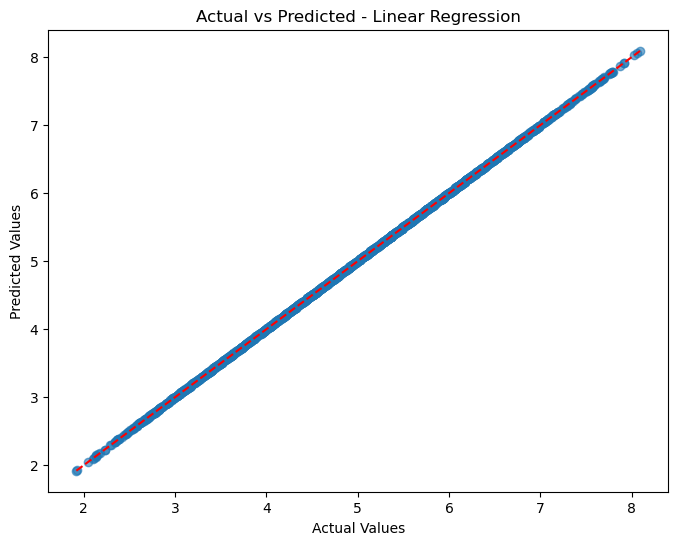

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()

# **Residual Plot**

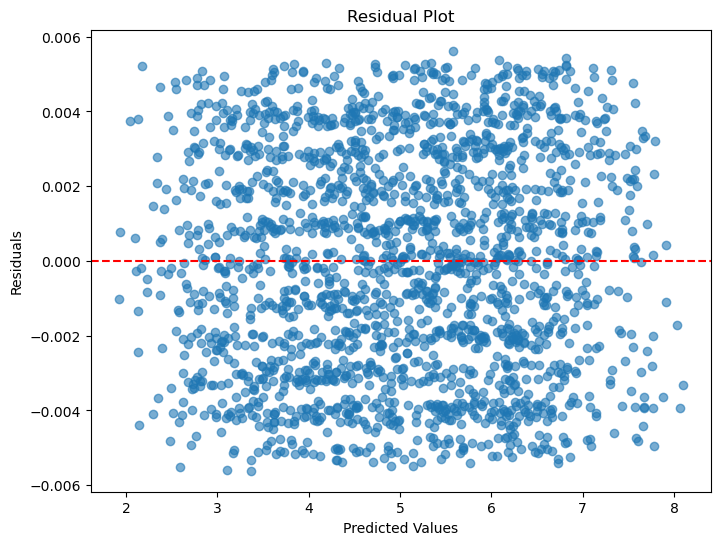

In [14]:
residuals = y_test - test_pred

plt.figure(figsize=(8,6))

plt.scatter(
    test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# **Residual Distribution**

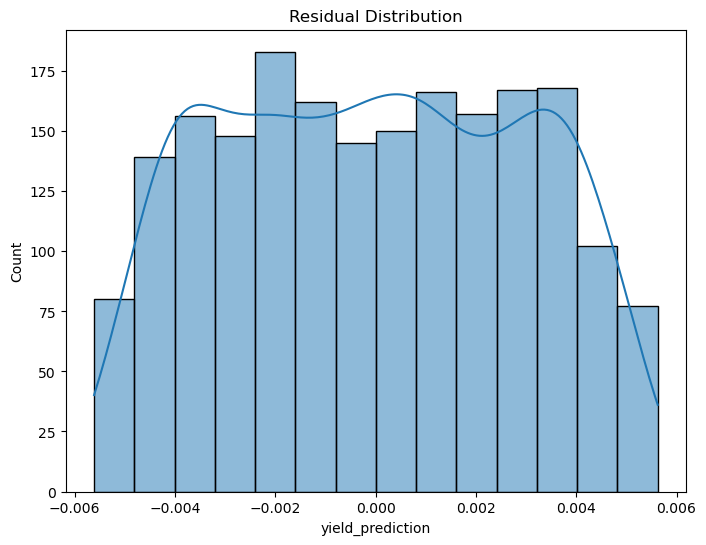

In [15]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

# **Coefficient Analysis**

In [16]:
coeff_df = pd.DataFrame({
    'Features': X.columns,
    'Coefficient': linear.coef_
})

coeff_df = coeff_df.sort_values(
    by='Coefficient',
    ascending=False
)

print("Top Positive Features")
print(coeff_df.head(10))

print("\nTop Negative Features")
print(coeff_df.tail(10))

Top Positive Features
                     Features  Coefficient
20                       ndvi     4.999855
16             organic_matter     0.199975
36        crop_type_Sugarcane     0.000223
34            crop_type_Maize     0.000170
33        irrigation_required     0.000086
38               region_North     0.000047
32    crop_water_stress_level     0.000046
37            crop_type_Wheat     0.000039
40                region_West     0.000038
45  irrigation_type_Sprinkler     0.000037

Top Negative Features
                 Features  Coefficient
43        soil_type_Silty    -0.000006
10          soil_moisture    -0.000007
9               dew_point    -0.000008
35         crop_type_Rice    -0.000017
26         previous_yield    -0.000018
44  irrigation_type_Flood    -0.000019
17                     ec    -0.000042
41        soil_type_Loamy    -0.000047
39           region_South    -0.000064
24           disease_risk    -0.009998


 # **2.Random Forest Regressor**

In [17]:
from sklearn.ensemble import RandomForestRegressor

random = RandomForestRegressor()
random.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
train_pred_rf = random.predict(X_train)
test_pred_rf = random.predict(X_test)

In [19]:
train_r2_rf = r2_score(y_train, train_pred_rf)

train_mae_rf = mean_absolute_error(y_train, train_pred_rf)

train_rmse_rf = mean_squared_error(y_train, train_pred_rf)

train_rmse_rf = train_rmse_rf ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_rf,4))
print("MAE      :", round(train_mae_rf,4))
print("MSE      :", round(train_rmse_rf,4))
print("RMSE     :", round(train_rmse_rf,4))



test_r2_rf = r2_score(y_test, test_pred_rf)

test_mae_rf = mean_absolute_error(y_test, test_pred_rf)

test_mse_rf = mean_squared_error(y_test, test_pred_rf)

test_rmse_rf = test_mse_rf ** 0.5

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_rf,4))
print("MAE      :", round(test_mae_rf,4))
print("MSE      :", round(test_mse_rf,4))
print("RMSE     :", round(test_rmse_rf,4))

===== Training Metrics =====
R² Score : 0.9996
MAE      : 0.0197
MSE      : 0.0255
RMSE     : 0.0255

===== Testing Metrics =====
R² Score : 0.9975
MAE      : 0.0514
MSE      : 0.0044
RMSE     : 0.0662


In [20]:
# check r2 score gap
r2_gap_rf = train_r2_rf - test_r2_rf

print("R2 Score Gap Is:",round(r2_gap_rf,4))

R2 Score Gap Is: 0.0022


# **Actual VS Predicted Plot**

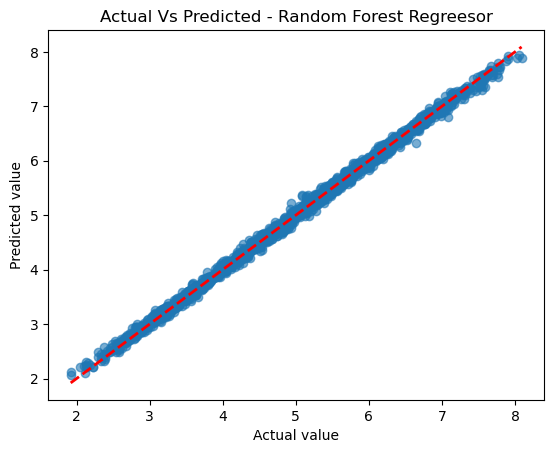

In [21]:
plt.scatter(y_test,test_pred_rf,alpha=0.6)
plt.plot( 
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Actual Vs Predicted - Random Forest Regreesor")
plt.show()

# **Resedual plot**

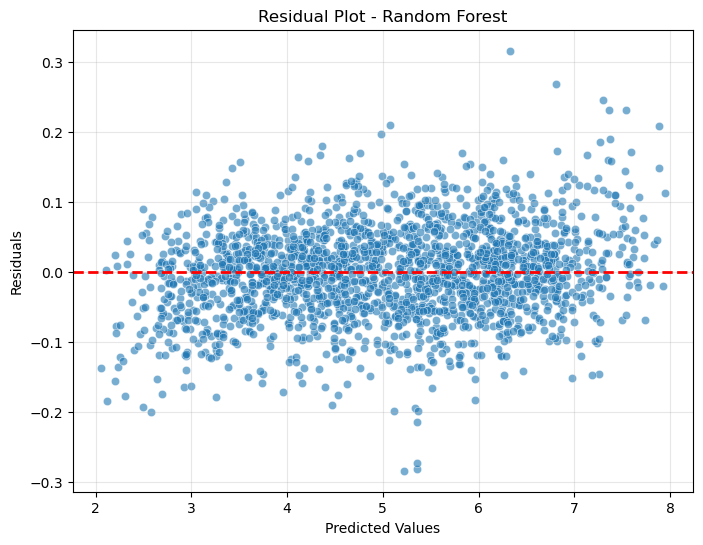

In [22]:
residuals_rf = y_test - test_pred_rf

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=test_pred_rf,
    y=residuals_rf,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Random Forest')

plt.grid(alpha=0.3)
plt.show()

# **Features Importance Table**

In [23]:

feature_importance = pd.DataFrame({
    'Features' : X.columns,
    'Importance' : random.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Positive Features")
print(feature_importance.head(10))

top_features_rf = feature_importance.head(10)


Top Positive Features
              Features  Importance
20                ndvi    0.852201
16      organic_matter    0.100314
24        disease_risk    0.043444
11    soil_temperature    0.000151
18        leaf_wetness    0.000147
19  evapotranspiration    0.000143
25   crop_health_index    0.000143
12             soil_ph    0.000141
9            dew_point    0.000141
28     reservoir_level    0.000140


C:\Users\Sourabh\AppData\Local\Temp\ipykernel_14340\550396542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


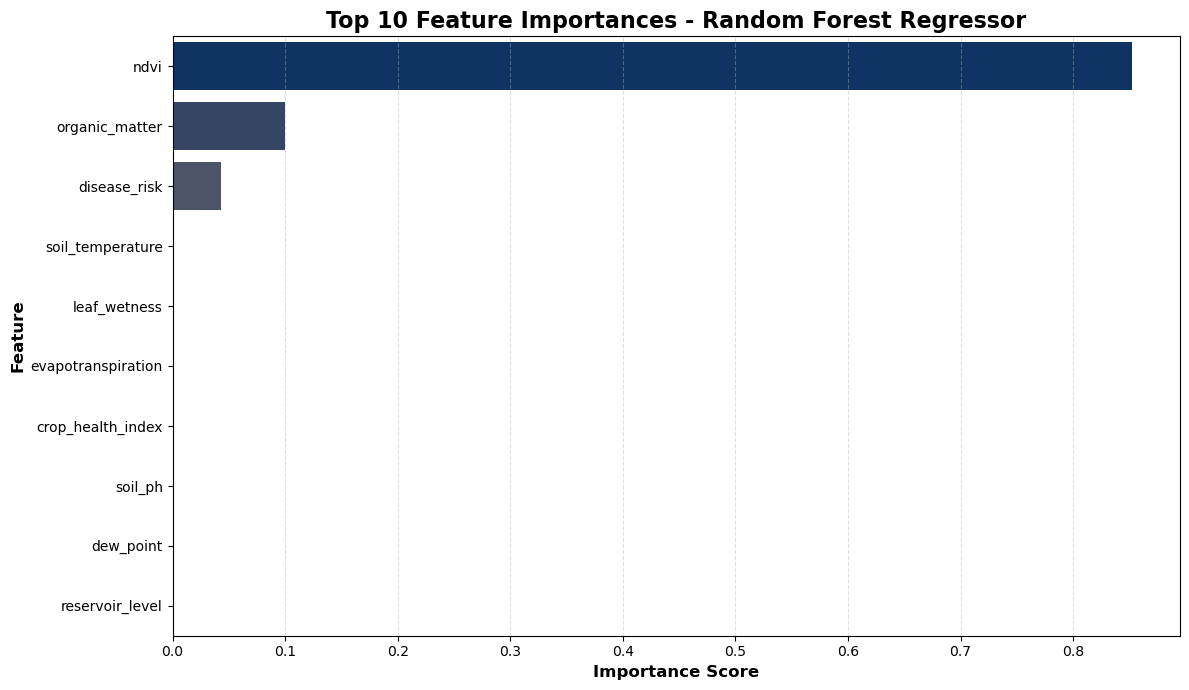

In [24]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_features_rf,
    x='Importance',
    y='Features',
    palette='cividis'
)

plt.title(
    'Top 10 Feature Importances - Random Forest Regressor',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Importance Score',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Feature',
    fontsize=12,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

# **Hyper-Parameter Tuning for Random Forest RegreSSor**

In [25]:
param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

In [26]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


In [27]:
from sklearn.model_selection import GridSearchCV

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [28]:
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [15, 20, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [29]:
best_rf = grid_search_rf.best_estimator_

In [30]:
print("Best Parameters:")
print(grid_search_rf.best_params_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [31]:
print("\nBest Cross Validation R² Score:")
print(round(grid_search_rf.best_score_,4))


Best Cross Validation R² Score:
0.9083


In [32]:
train_pred_rf_tune = best_rf.predict(X_train)

test_pred_rf_tune = best_rf.predict(X_test)

In [33]:
# Training Metrics
train_r2_rf_tune = r2_score(y_train, train_pred_rf_tune)

# Testing Metrics
test_r2_rf_tune = r2_score(y_test, test_pred_rf_tune)

mae_rf_tune = mean_absolute_error(y_test, test_pred_rf_tune)

mse_rf_tune = mean_squared_error(y_test, test_pred_rf_tune)

rmse_rf_tune = mse_rf_tune ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_rf,4))

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_rf,4))
print("MAE      :", round(mae_rf_tune,4))
print("MSE      :", round(mse_rf_tune,4))
print("RMSE     :", round(rmse_rf_tune,4))

===== Training Metrics =====
R² Score : 0.9996

===== Testing Metrics =====
R² Score : 0.9975
MAE      : 0.2942
MSE      : 0.1394
RMSE     : 0.3734


In [34]:
r2_gap_rf = train_r2_rf - test_r2_rf

print("R² Score Gap Is:", round(r2_gap_rf,4))

R² Score Gap Is: 0.0022


# **Feature IMportance**

In [35]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_rf.head(10))

               Feature  Importance
20                ndvi    0.640517
16      organic_matter    0.082858
24        disease_risk    0.039038
8          cloud_cover    0.008788
19  evapotranspiration    0.008489
4    forecast_rainfall    0.008414
22         water_usage    0.008366
9            dew_point    0.008245
1          temperature    0.008187
6      solar_radiation    0.008137


C:\Users\Sourabh\AppData\Local\Temp\ipykernel_14340\2528136506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


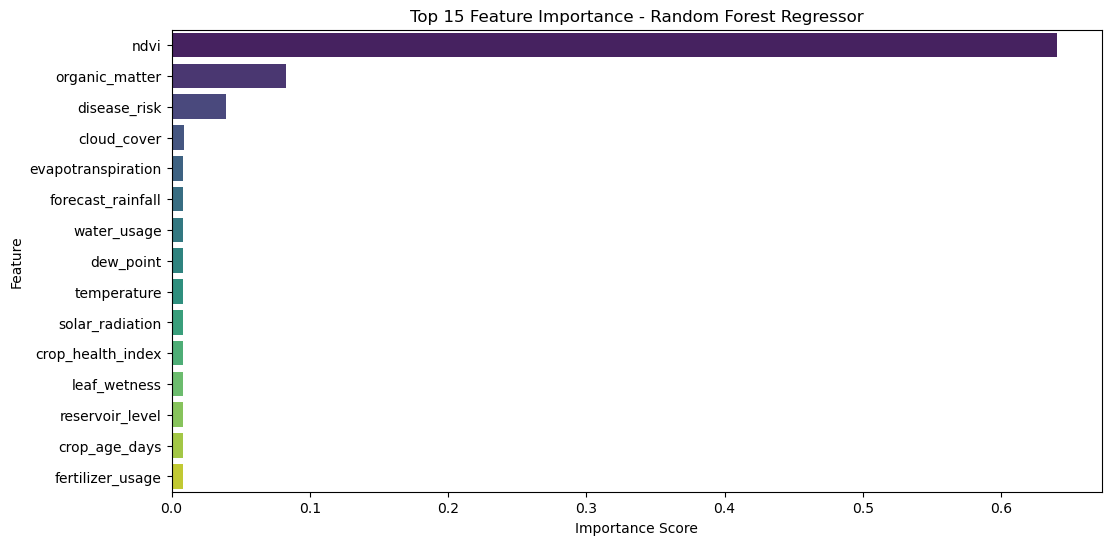

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance_rf.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 15 Feature Importance - Random Forest Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

# **3.XGBoost Regressor**

In [37]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, n_estimators=200,
    max_depth=6,
    learning_rate=0.05,)
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
train_pred_xgb = xgb.predict(X_train)

test_pred_xgb = xgb.predict(X_test)

In [39]:
# Training Metrics
train_r2_xgb = r2_score(y_train, train_pred_xgb)

# Testing Metrics
test_r2_xgb = r2_score(y_test, test_pred_xgb)

mae_xgb = mean_absolute_error(y_test, test_pred_xgb)

mse_xgb = mean_squared_error(y_test, test_pred_xgb)

rmse_xgb = mse_xgb ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_xgb,4))

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_xgb,4))
print("MAE      :", round(mae_xgb,4))
print("MSE      :", round(mse_xgb,4))
print("RMSE     :", round(rmse_xgb,4))

===== Training Metrics =====
R² Score : 0.9997

===== Testing Metrics =====
R² Score : 0.9993
MAE      : 0.0279
MSE      : 0.0013
RMSE     : 0.0355


In [40]:
r2_gap_xgb = train_r2_xgb - test_r2_xgb

print("R² Score Gap Is:", round(r2_gap_xgb,4))

R² Score Gap Is: 0.0005


# **Actual VS Predicted Plot**

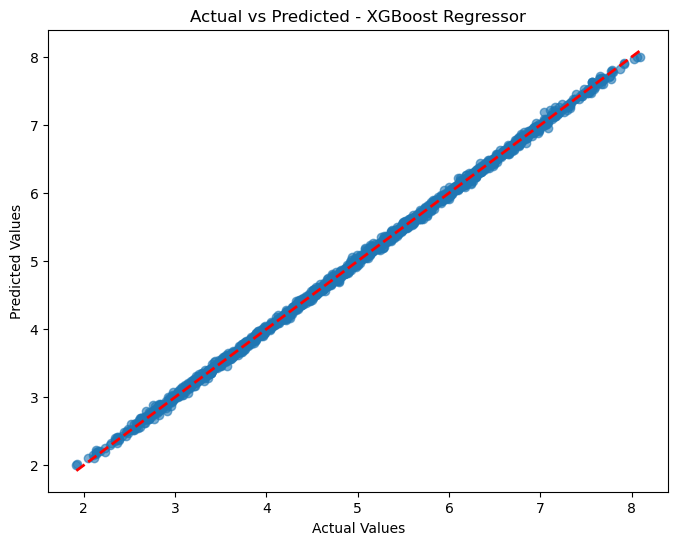

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    test_pred_xgb,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - XGBoost Regressor")

plt.show()

# **Residual Plot**

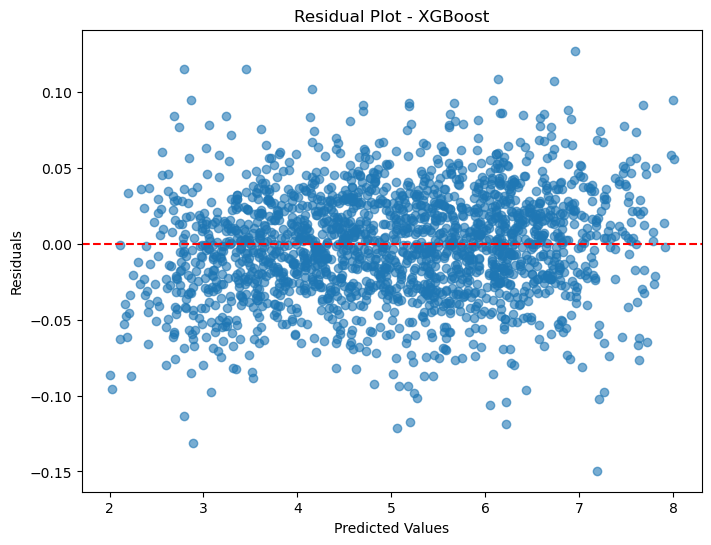

In [42]:
residuals_xgb = y_test - test_pred_xgb

plt.figure(figsize=(8,6))

plt.scatter(
    test_pred_xgb,
    residuals_xgb,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - XGBoost")

plt.show()

# **Residual Distribution**

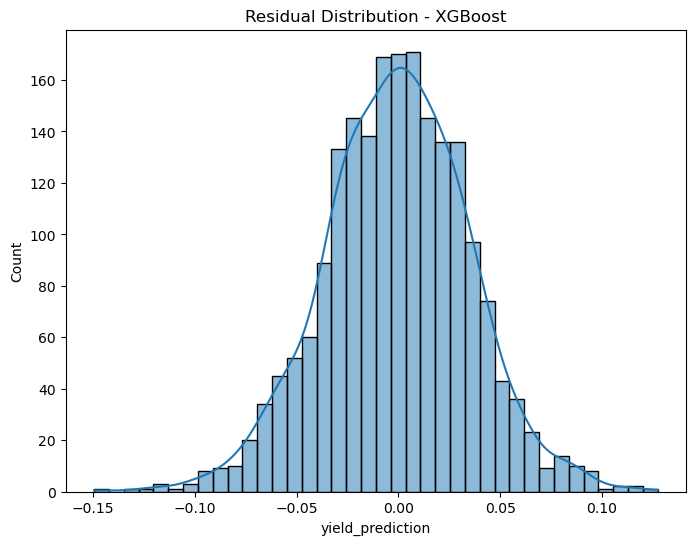

In [43]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals_xgb,
    kde=True
)

plt.title("Residual Distribution - XGBoost")

plt.show()

# **Feature Importance**

In [44]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

print("Top 10 Important Features")
print(feature_importance_xgb.head(10))

Top 10 Important Features
              Feature  Importance
20               ndvi    0.885968
16     organic_matter    0.074370
24       disease_risk    0.037786
27  groundwater_level    0.000069
38       region_North    0.000061
34    crop_type_Maize    0.000060
10      soil_moisture    0.000056
21      crop_age_days    0.000054
23          pest_risk    0.000053
30        labor_hours    0.000052


C:\Users\Sourabh\AppData\Local\Temp\ipykernel_14340\2730806157.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


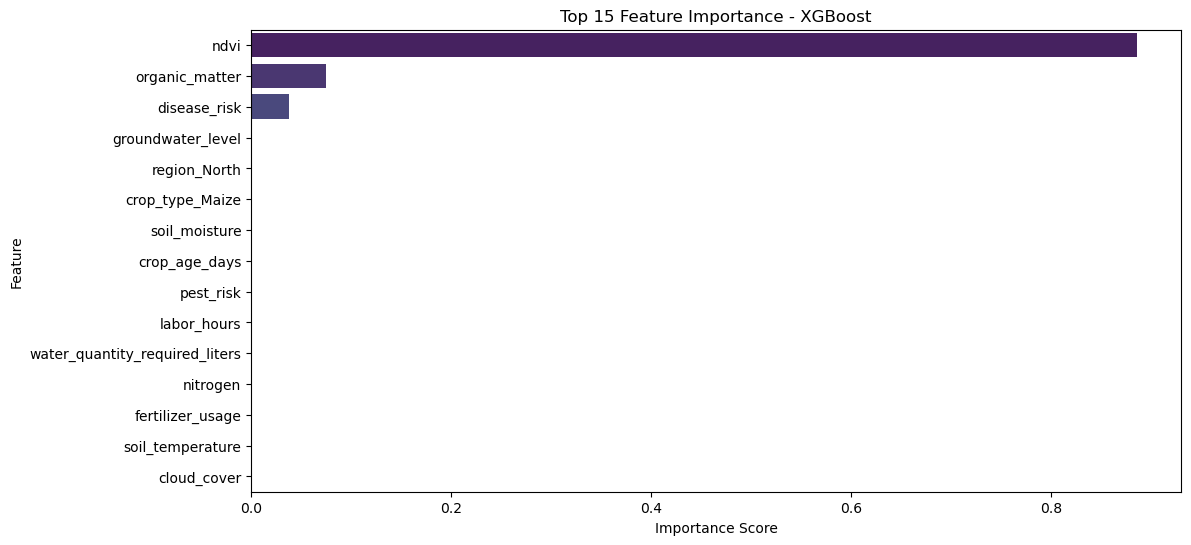

In [45]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance_xgb.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 15 Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

# **Comparison Of All Models**

In [46]:
comparison_df = pd.DataFrame({

    'Metric': [
        'Train R²',
        'Test R²',
        'MAE',
        'RMSE'
    ],

    'Linear Regression': [
        round(train_r2_score,4),
        round(test_r2_score,4),
        round(mae,4),
        round(rmse,4)
    ],

    'Random Forest': [
        round(train_r2_rf_tune,4),
        round(test_r2_rf_tune,4),
        round(mae_rf_tune,4),
        round(rmse_rf_tune,4)
    ],

    'XGBoost': [
        round(train_r2_xgb,4),
        round(test_r2_xgb,4),
        round(mae_xgb,4),
        round(rmse_xgb,4)
    ]

})

print(comparison_df)

     Metric  Linear Regression  Random Forest  XGBoost
0  Train R²             1.0000         0.9844   0.9997
1   Test R²             1.0000         0.9201   0.9993
2       MAE             0.0025         0.2942   0.0279
3      RMSE             0.0030         0.3734   0.0355


I compared Linear Regression, Random Forest Regressor, and XGBoost Regressor using R² Score, MAE, and RMSE. Linear Regression achieved the highest Test R² (1.0000) and the lowest MAE and RMSE. Since the relationship between the target variable and the key predictors was highly linear, Linear Regression generalized better while also being simpler and more interpretable than ensemble models. Therefore, Linear Regression was selected as the final model for yield prediction.


# **Save Model**

In [47]:
import joblib

joblib.dump(xgb, "../models/yield_prediction_model.pkl")

joblib.dump(
    X.columns.tolist(),
    "../models/yield_prediction_features.pkl"
)

['../models/yield_prediction_features.pkl']

In [48]:
corr = df.corr(numeric_only=True)

print(
    corr["yield_prediction"]
    .sort_values(ascending=False)
    .head(20)
)

yield_prediction                  1.000000
ndvi                              0.921417
organic_matter                    0.331314
pest_risk                         0.033559
crop_age_days                     0.023720
dew_point                         0.014208
temperature                       0.013142
forecast_rainfall                 0.010509
potassium                         0.009670
evapotranspiration                0.009526
crop_type_Sugarcane               0.008853
irrigation_type_Sprinkler         0.007336
growth_stage                      0.006991
water_quantity_required_liters    0.006817
fertilizer_usage                  0.006239
solar_radiation                   0.006231
soil_ph                           0.006160
region_North                      0.006001
future_soil_moisture_3day         0.005581
soil_moisture                     0.005301
Name: yield_prediction, dtype: float64


In [49]:
corr = df.corr(numeric_only=True)

print(
    corr["yield_prediction"]
    .abs()
    .sort_values(ascending=False)
    .head(13)
)

yield_prediction           1.000000
ndvi                       0.921417
organic_matter             0.331314
disease_risk               0.206871
pest_risk                  0.033559
crop_age_days              0.023720
humidity                   0.020165
dew_point                  0.014208
rainfall                   0.013538
temperature                0.013142
forecast_rainfall          0.010509
crop_water_stress_level    0.010169
wind_speed                 0.010073
Name: yield_prediction, dtype: float64


In [50]:
joblib.dump(
    linear,
    "../models/yield_prediction_model_lr_backup.pkl"
)

['../models/yield_prediction_model_lr_backup.pkl']

In [52]:
# ensure the model and feature list are loaded (safe to run this cell before/after loader cells)
if "yield_model" not in globals():
    import os
    import joblib

    models_dir = os.path.normpath(os.path.join("..", "models"))

    # load feature list (fallback to X.columns if file missing)
    try:
        yield_features = joblib.load(os.path.join(models_dir, "yield_prediction_features.pkl"))
    except Exception:
        yield_features = X.columns.tolist()

    # load model (try main name, then backups)
    for name in ("yield_prediction_model.pkl",
                 "yield_prediction_model_lr_backup.pkl",
                 "yield_prediction_model_lr.pkl"):
        path = os.path.join(models_dir, name)
        if os.path.exists(path):
            yield_model = joblib.load(path)
            break
    else:
        raise FileNotFoundError(f"No yield model found in {models_dir}. Available: {os.listdir(models_dir)}")

# get a sample row and predict
row = df[df["yield_prediction"] == 6.04].iloc[0]

X_row = row[yield_features]

pred = yield_model.predict(pd.DataFrame([X_row]))[0]

print("Actual:", row["yield_prediction"])
print("Predicted:", pred)

Actual: 6.04
Predicted: 6.008624


In [53]:
# ...existing code...
import os
import joblib
import pandas as pd

models_dir = os.path.normpath(os.path.join("..", "models"))

# load feature list (fallback to X.columns if file missing)
try:
    yield_features = joblib.load(os.path.join(models_dir, "yield_prediction_features.pkl"))
except Exception:
    yield_features = X.columns.tolist()  # requires X to exist in the notebook

# load model (try main name, then backups)
for name in ("yield_prediction_model.pkl",
             "yield_prediction_model_lr_backup.pkl",
             "yield_prediction_model_lr.pkl"):
    path = os.path.join(models_dir, name)
    if os.path.exists(path):
        yield_model = joblib.load(path)
        break
else:
    raise FileNotFoundError(f"No yield model found in {models_dir}. Available: {os.listdir(models_dir)}")

print("Loaded model and features:", path, len(yield_features))
# ...existing code...

Loaded model and features: ..\models\yield_prediction_model.pkl 46


In [54]:
default_values = {
    "humidity": df["humidity"].mean(),
    "wind_speed": df["wind_speed"].mean(),
    "solar_radiation": df["solar_radiation"].mean(),
    "pressure": df["pressure"].mean(),
    "cloud_cover": df["cloud_cover"].mean(),
    "dew_point": df["dew_point"].mean(),
    "soil_temperature": df["soil_temperature"].mean(),
    "soil_ph": df["soil_ph"].mean(),
    "nitrogen": df["nitrogen"].mean(),
    "phosphorus": df["phosphorus"].mean(),
    "potassium": df["potassium"].mean(),
    "organic_matter": df["organic_matter"].mean(),
    "ec": df["ec"].mean(),
    "leaf_wetness": df["leaf_wetness"].mean(),
    "crop_age_days": df["crop_age_days"].mean(),
    "water_usage": df["water_usage"].mean(),
    "pest_risk": df["pest_risk"].mean(),
    "disease_risk": df["disease_risk"].mean(),
    "crop_health_index": df["crop_health_index"].mean(),
    "previous_yield": df["previous_yield"].mean(),
    "groundwater_level": df["groundwater_level"].mean(),
    "reservoir_level": df["reservoir_level"].mean(),
    "fertilizer_usage": df["fertilizer_usage"].mean(),
    "labor_hours": df["labor_hours"].mean()
}

print(default_values)

{'humidity': np.float64(57.259388), 'wind_speed': np.float64(14.978688), 'solar_radiation': np.float64(551.289992), 'pressure': np.float64(999.6037210000001), 'cloud_cover': np.float64(49.889210999999996), 'dew_point': np.float64(15.087630000000003), 'soil_temperature': np.float64(25.139476), 'soil_ph': np.float64(6.532541999999999), 'nitrogen': np.float64(74.2918), 'phosphorus': np.float64(62.1759), 'potassium': np.float64(77.6604), 'organic_matter': np.float64(4.260173), 'ec': np.float64(1.555951), 'leaf_wetness': np.float64(49.68676), 'crop_age_days': np.float64(89.3602), 'water_usage': np.float64(523.029872), 'pest_risk': np.float64(49.7808), 'disease_risk': np.float64(49.9163), 'crop_health_index': np.float64(70.056901), 'previous_yield': np.float64(5.480929), 'groundwater_level': np.float64(25.474697999999997), 'reservoir_level': np.float64(54.88290500000001), 'fertilizer_usage': np.float64(154.97437), 'labor_hours': np.float64(10.471016)}


In [55]:
import joblib

joblib.dump(
    default_values,
    "../models/yield_default_values.pkl"
)

['../models/yield_default_values.pkl']

In [56]:
yield_defaults = joblib.load(
    "../models/yield_default_values.pkl"
)

In [57]:
print(yield_features)

['growth_stage', 'temperature', 'humidity', 'rainfall', 'forecast_rainfall', 'wind_speed', 'solar_radiation', 'pressure', 'cloud_cover', 'dew_point', 'soil_moisture', 'soil_temperature', 'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'organic_matter', 'ec', 'leaf_wetness', 'evapotranspiration', 'ndvi', 'crop_age_days', 'water_usage', 'pest_risk', 'disease_risk', 'crop_health_index', 'previous_yield', 'groundwater_level', 'reservoir_level', 'fertilizer_usage', 'labor_hours', 'water_quantity_required_liters', 'crop_water_stress_level', 'irrigation_required', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Sugarcane', 'crop_type_Wheat', 'region_North', 'region_South', 'region_West', 'soil_type_Loamy', 'soil_type_Sandy', 'soil_type_Silty', 'irrigation_type_Flood', 'irrigation_type_Sprinkler']
